In [ ]:
!pip install  pyarrow tqdm matplotlib paramiko

In [ ]:
import os
import time
import requests
import gzip
import tarfile

# Create download directory
download_dir = 'hapmap_data'
os.makedirs(download_dir, exist_ok=True)

# File URLs and their target filenames
file_urls = {
    'hapmap3_r3_b36_fwd.consensus.qc.poly.map.gz':
        'https://ftp.ncbi.nlm.nih.gov/hapmap/genotypes/hapmap3_r3/plink_format/hapmap3_r3_b36_fwd.consensus.qc.poly.map.gz',
    'hapmap3_r3_b36_fwd.qc.poly.tar.gz':
        'https://ftp.ncbi.nlm.nih.gov/hapmap/genotypes/hapmap3_r3/plink_format/hapmap3_r3_b36_fwd.qc.poly.tar.gz',
    'relationships_w_pops_041510.txt':
        'https://ftp.ncbi.nlm.nih.gov/hapmap/genotypes/hapmap3_r3/relationships_w_pops_041510.txt'
}

# Function to download a file with progress display
def download_file(filename, url, save_dir):
    save_path = os.path.join(save_dir, filename)
    try:
        print(f"Downloading: {filename}")
        response = requests.get(url, stream=True)
        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))
        total_size_mb = total_size / (1024 * 1024)
        print(f"File size: {total_size_mb:.2f} MB")

        with open(save_path, 'wb') as f:
            downloaded = 0
            start_time = time.time()

            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    # Print progress every 5MB
                    if downloaded % (5 * 1024 * 1024) == 0:
                        elapsed = time.time() - start_time
                        speed = downloaded / (1024 * 1024 * elapsed) if elapsed > 0 else 0
                        percent = (downloaded / total_size * 100) if total_size > 0 else 0
                        print(f"Downloaded: {downloaded/(1024*1024):.2f} MB "
                              f"({percent:.1f}%) at {speed:.2f} MB/s")

        print(f"Download complete: {filename}\n{'-'*50}")
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

# Function to extract .gz file
def extract_gzip_file(gz_path, output_path):
    try:
        with gzip.open(gz_path, 'rb') as f_in, open(output_path, 'wb') as f_out:
            f_out.write(f_in.read())
        print(f"Extracted: {gz_path} → {output_path}")
    except Exception as e:
        print(f"Error extracting gzip file {gz_path}: {e}")

# Function to extract .tar.gz file
def extract_tar_gz_file(tar_gz_path, output_dir):
    try:
        with tarfile.open(tar_gz_path, 'r:gz') as tar:
            tar.extractall(path=output_dir)
        print(f"Extracted: {tar_gz_path} → {output_dir}")
    except Exception as e:
        print(f"Error extracting tar.gz file {tar_gz_path}: {e}")

# Download all files
for name, url in file_urls.items():
    download_file(name, url, download_dir)

print("All downloads completed.\n")

# Extract downloaded compressed files
map_gz_path = os.path.join(download_dir, 'hapmap3_r3_b36_fwd.consensus.qc.poly.map.gz')
map_output_path = os.path.join(download_dir, 'hapmap3_r3_b36_fwd.consensus.qc.poly.map')
if os.path.exists(map_gz_path):
    extract_gzip_file(map_gz_path, map_output_path)

tar_gz_path = os.path.join(download_dir, 'hapmap3_r3_b36_fwd.qc.poly.tar.gz')
if os.path.exists(tar_gz_path):
    extract_tar_gz_file(tar_gz_path, download_dir)

print("All extractions completed.")

In [ ]:
!pip install scikit-learn==1.2.2 pyarrow tqdm matplotlib paramiko imbalanced-learn umap-learn xgboost lightgbm

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Import Libraries
</div>

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import gc
import warnings
warnings.filterwarnings('ignore')

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Initialize Paths and Settings
</div>

In [6]:
print("Initializing paths and settings...")
data_dir = 'hapmap_data'
map_file = os.path.join(data_dir, 'hapmap3_r3_b36_fwd.consensus.qc.poly.map')
relationships_file = os.path.join(data_dir, 'relationships_w_pops_041510.txt')
output_dir = os.path.join(data_dir, 'improved_data')
os.makedirs(output_dir, exist_ok=True)

ped_files = glob.glob(os.path.join(data_dir, 'hapmap3_r2_b36_fwd.qc.poly', '*.ped'), recursive=True)
if not ped_files:
    raise FileNotFoundError("No PED files found. Make sure the archive was extracted correctly.")

print(f"Found {len(ped_files)} PED files for different populations")

Initializing paths and settings...
Found 11 PED files for different populations


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Reading Relationships and Populations
</div>

In [7]:
print("\nReading relationships and populations file...")
relationships_df = pd.read_csv(relationships_file, sep='\s+', low_memory=False)
print(f"Relationships file read. Dimensions: {relationships_df.shape}")


Reading relationships and populations file...
Relationships file read. Dimensions: (1397, 7)


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Reading SNP Map File
</div>

In [9]:
print("\nReading map file (SNPs information)...")
map_columns = ['CHR', 'SNP', 'GEN_DIST', 'POS']
map_df = pd.read_csv(map_file, sep='\s+', header=None, names=map_columns)
print(f"Map file read. Number of SNPs: {map_df.shape[0]}")

MAX_SNPS = 300000
if map_df.shape[0] > MAX_SNPS:
    print(f"\nUsing first {MAX_SNPS} SNPs out of {map_df.shape[0]} to speed up processing...")
    map_df = map_df.iloc[:MAX_SNPS]
    print(f"Number of SNPs limited. New SNP count: {map_df.shape[0]}")


Reading map file (SNPs information)...
Map file read. Number of SNPs: 1457897

Using first 300000 SNPs out of 1457897 to speed up processing...
Number of SNPs limited. New SNP count: 300000


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Reading Sample Information
</div>

In [10]:
print("\nReading sample information from PED files...")
all_samples_info = []
population_labels = {}

for ped_file in ped_files:
    file_basename = os.path.basename(ped_file)
    population = file_basename.split('.')[1] if len(file_basename.split('.')) > 2 else "Unknown"
    
    ped_columns = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENO']
    dtype_dict = {0: str, 1: str, 2: str, 3: str, 4: int, 5: int}
    
    ped_info_df = pd.read_csv(ped_file, sep='\s+', header=None, usecols=range(6), 
                             names=ped_columns, dtype=dtype_dict, low_memory=False)
    
    ped_info_df['FILE_POP'] = population
    
    all_samples_info.append(ped_info_df)
    
    for idx, row in ped_info_df.iterrows():
        population_labels[row['IID']] = population

all_samples_df = pd.concat(all_samples_info, ignore_index=True)
print(f"Collected information for {all_samples_df.shape[0]} samples from {len(ped_files)} populations.")


Reading sample information from PED files...
Collected information for 1397 samples from 11 populations.


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Merge Sample Information with Relationships
</div>

In [11]:
merged_samples_df = pd.merge(
    all_samples_df,
    relationships_df,
    on='IID',
    how='left',
    suffixes=('_ped', '_rel')
)

print("\nPopulation distribution in the data:")
population_counts = merged_samples_df['FILE_POP'].value_counts()
print(population_counts)

samples_info_file = os.path.join(output_dir, 'all_samples_info.csv')
merged_samples_df.to_csv(samples_info_file, index=False)
print(f"Sample information saved to: {samples_info_file}")


Population distribution in the data:
FILE_POP
YRI    203
MKK    184
CEU    165
CHB    137
JPT    113
LWK    110
CHD    109
TSI    102
GIH    101
ASW     87
MEX     86
Name: count, dtype: int64
Sample information saved to: hapmap_data/improved_data/all_samples_info.csv


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Define Genotype Encoding Function
</div>

In [12]:
def improved_encoding(genotype_data):
    """Improved encoding for genetic data using additive inheritance model"""
    encoded_data = np.zeros((genotype_data.shape[0], genotype_data.shape[1] // 2), dtype=np.float32)
    
    for i in range(0, genotype_data.shape[1], 2):
        allele1 = genotype_data[:, i]
        allele2 = genotype_data[:, i+1]
        snp_idx = i // 2
        
        unique_alleles, counts = np.unique(np.concatenate([allele1, allele2]), return_counts=True)
        
        if len(unique_alleles) > 0:
            ref_allele = unique_alleles[np.argmax(counts)]
            
            alt_count = np.zeros(allele1.shape[0], dtype=np.float32)
            alt_count += (allele1 != ref_allele) & (allele1 != '0')
            alt_count += (allele2 != ref_allele) & (allele2 != '0')
            
            encoded_data[:, snp_idx] = alt_count
    
    return encoded_data

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Extract and Encode Genetic Data
</div>

In [13]:
print("\nStarting extraction and encoding of genetic data...")

all_genotype_data = []
all_samples_ids = []

for ped_file in tqdm(ped_files, desc="Processing PED files"):
    ped_columns = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENO']
    ped_info = pd.read_csv(ped_file, sep='\s+', header=None, usecols=range(6), 
                          names=ped_columns, low_memory=False)
    
    n_samples = ped_info.shape[0]
    sample_ids = ped_info['IID'].tolist()
    all_samples_ids.extend(sample_ids)
    
    total_columns = 6 + (MAX_SNPS * 2)
    
    try:
        column_indices = list(range(6)) + list(range(6, 6 + (MAX_SNPS * 2)))
        genotype_data = pd.read_csv(ped_file, sep='\s+', header=None, usecols=column_indices, low_memory=False)
        
        snp_data = genotype_data.iloc[:, 6:].values
        
        encoded_data = improved_encoding(snp_data)
        
        all_genotype_data.append(encoded_data)
        
        print(f"Processed {encoded_data.shape[0]} samples and {encoded_data.shape[1]} SNPs from file {os.path.basename(ped_file)}")
        
        del genotype_data, snp_data
        gc.collect()
        
    except Exception as e:
        print(f"Error processing file {ped_file}: {str(e)}")
        continue


Starting extraction and encoding of genetic data...


Processing PED files:   9%|▉         | 1/11 [01:30<15:09, 90.92s/it]

Processed 109 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CHD.qc.poly.ped


Processing PED files:  18%|█▊        | 2/11 [03:09<14:20, 95.61s/it]

Processed 137 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CHB.qc.poly.ped


...

Processed 165 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CEU.qc.poly.ped


Processing PED files:  91%|█████████ | 10/11 [16:45<01:52, 112.31s/it]

Processed 203 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.YRI.qc.poly.ped


Processing PED files: 100%|██████████| 11/11 [17:59<00:00, 98.10s/it] 

Processed 87 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.ASW.qc.poly.ped


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Merge Genetic Data
</div>

In [14]:
print("\nMerging genetic data from all files...")
all_genotypes = np.vstack(all_genotype_data)
print(f"Genetic data combined. Dimensions: {all_genotypes.shape}")

del all_genotype_data
gc.collect()


Merging genetic data from all files...
Genetic data combined. Dimensions: (1397, 300000)


0

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Prepare Sample Metadata
</div>

In [15]:
samples_df = pd.DataFrame({
    'IID': all_samples_ids,
    'Population': [population_labels[id] for id in all_samples_ids]
})

print("\nEncoding populations...")
le = LabelEncoder()
samples_df['Population_encoded'] = le.fit_transform(samples_df['Population'])
population_classes = le.classes_

samples_df = pd.merge(
    samples_df,
    merged_samples_df[['IID', 'SEX']],
    on='IID',
    how='left'
)

print("\nPopulation distribution after merging:")
print(samples_df['Population'].value_counts())


Encoding populations...

Population distribution after merging:
Population
YRI    203
MKK    184
CEU    165
CHB    137
JPT    113
LWK    110
CHD    109
TSI    102
GIH    101
ASW     87
MEX     86
Name: count, dtype: int64


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Feature Selection
</div>

In [16]:
print("\nSelecting best SNPs for classification...")
X = all_genotypes
y = samples_df['Population_encoded'].values

selector = SelectKBest(f_classif, k=10000)
X_selected = selector.fit_transform(X, y)

print(f"Selected {X_selected.shape[1]} SNPs out of {X.shape[1]} SNPs.")
print(f"Dimensions of selected data: {X_selected.shape}")

selected_indices = selector.get_support(indices=True)
selected_snps = map_df.iloc[selected_indices]
selected_snps.to_csv(os.path.join(output_dir, 'selected_snps.csv'), index=False)
print(f"List of selected SNPs saved to: {os.path.join(output_dir, 'selected_snps.csv')}")


Selecting best SNPs for classification...
Selected 10000 SNPs out of 300000 SNPs.
Dimensions of selected data: (1397, 10000)
List of selected SNPs saved to: hapmap_data/improved_data/selected_snps.csv


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Dimensionality Reduction (PCA)
</div>

In [17]:
print("\nApplying PCA to selected data...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_selected)

print(f"Dimensions reduced to {X_pca.shape[1]} principal components.")
print(f"Explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}")


Applying PCA to selected data...
Dimensions reduced to 50 principal components.
Explained variance ratio: 0.3860


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
PCA Visualization - Variance
</div>

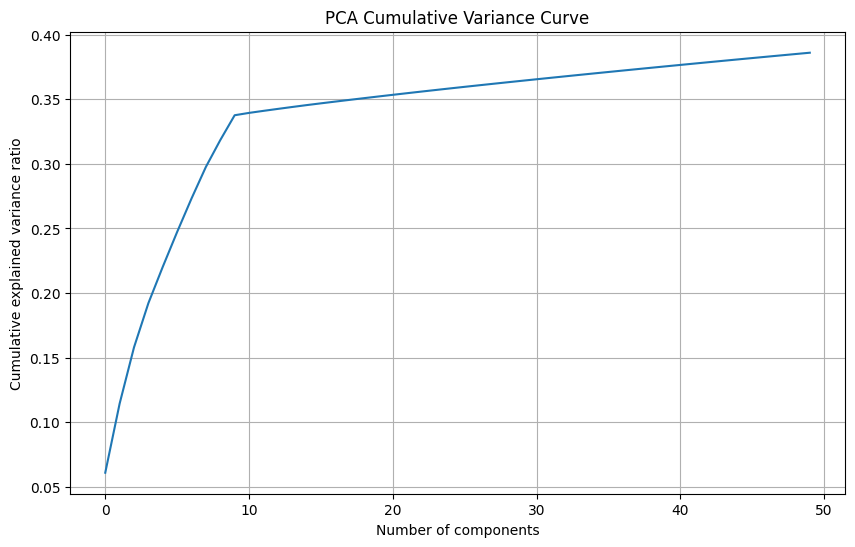

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance ratio')
plt.title('PCA Cumulative Variance Curve')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'pca_variance.png'))

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
PCA Visualization - Population Distribution
</div>

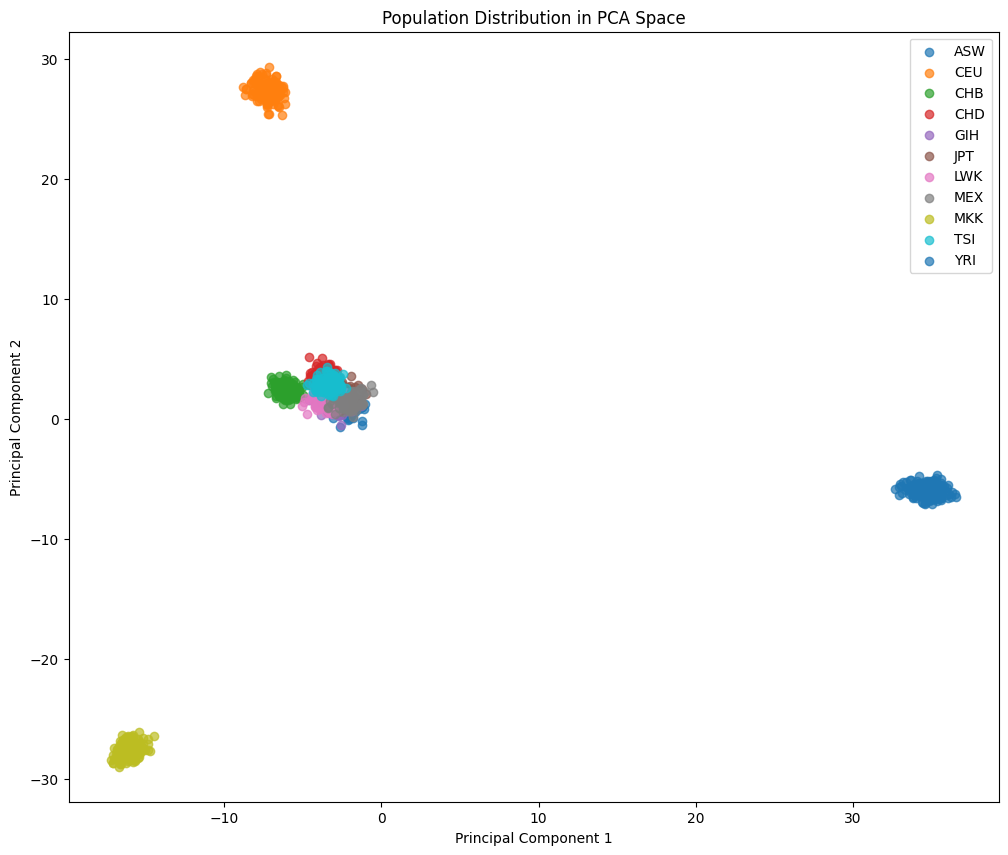

In [19]:
plt.figure(figsize=(12, 10))
for i, pop in enumerate(population_classes):
    pop_mask = samples_df['Population'] == pop
    plt.scatter(
        X_pca[pop_mask, 0], 
        X_pca[pop_mask, 1],
        label=pop, 
        alpha=0.7
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Population Distribution in PCA Space')
plt.legend()
plt.savefig(os.path.join(output_dir, 'pca_populations.png'))

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Save PCA Features
</div>

In [20]:
features_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
features_df['IID'] = samples_df['IID'].values
features_df['Population'] = samples_df['Population'].values
features_df['SEX'] = samples_df['SEX'].values

features_file = os.path.join(output_dir, 'genetic_features_pca.csv')
features_df.to_csv(features_file, index=False)
print(f"Extracted features saved to: {features_file}")

Extracted features saved to: hapmap_data/improved_data/genetic_features_pca.csv


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Prepare Data for Modeling
</div>

In [23]:
print("\nPreparing data for modeling...")

feature_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
features_df['SEX_numeric'] = features_df['SEX'].fillna(0).astype(int)
feature_columns.append('SEX_numeric')

X = features_df[feature_columns].values
y = le.transform(features_df['Population'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Preparing data for modeling...
Training set: 1117 samples
Test set: 280 samples


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Handle Class Imbalance with SMOTE
</div>

In [24]:
print("\nApplying SMOTE to handle data imbalance...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Size of training set after SMOTE: {X_train_balanced.shape[0]} samples")
print("Population distribution after SMOTE:")
for pop_idx, count in zip(*np.unique(y_train_balanced, return_counts=True)):
    print(f"{le.inverse_transform([pop_idx])[0]}: {count} samples")


Applying SMOTE to handle data imbalance...
Size of training set after SMOTE: 1782 samples
Population distribution after SMOTE:
ASW: 162 samples
CEU: 162 samples
CHB: 162 samples
CHD: 162 samples
GIH: 162 samples
JPT: 162 samples
LWK: 162 samples
MEX: 162 samples
MKK: 162 samples
TSI: 162 samples
YRI: 162 samples


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Model Parameter Tuning
</div>

In [25]:
print("\nTuning model parameters...")
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight': [None, 'balanced']
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

print("Searching for best parameters...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


Tuning model parameters...
Searching for best parameters...
Best parameters: {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best cross-validation accuracy: 1.0000


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Model Evaluation
</div>

In [26]:
y_pred = best_model.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=population_classes))


Classification report:
              precision    recall  f1-score   support

         ASW       1.00      1.00      1.00        17
         CEU       1.00      1.00      1.00        33
         CHB       1.00      1.00      1.00        28
         CHD       1.00      1.00      1.00        22
         GIH       1.00      1.00      1.00        20
         JPT       1.00      1.00      1.00        23
         LWK       1.00      1.00      1.00        22
         MEX       1.00      1.00      1.00        17
         MKK       1.00      1.00      1.00        37
         TSI       1.00      1.00      1.00        20
         YRI       1.00      1.00      1.00        41

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280



<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Confusion Matrix Visualization
</div>


Overall model accuracy: 1.0000


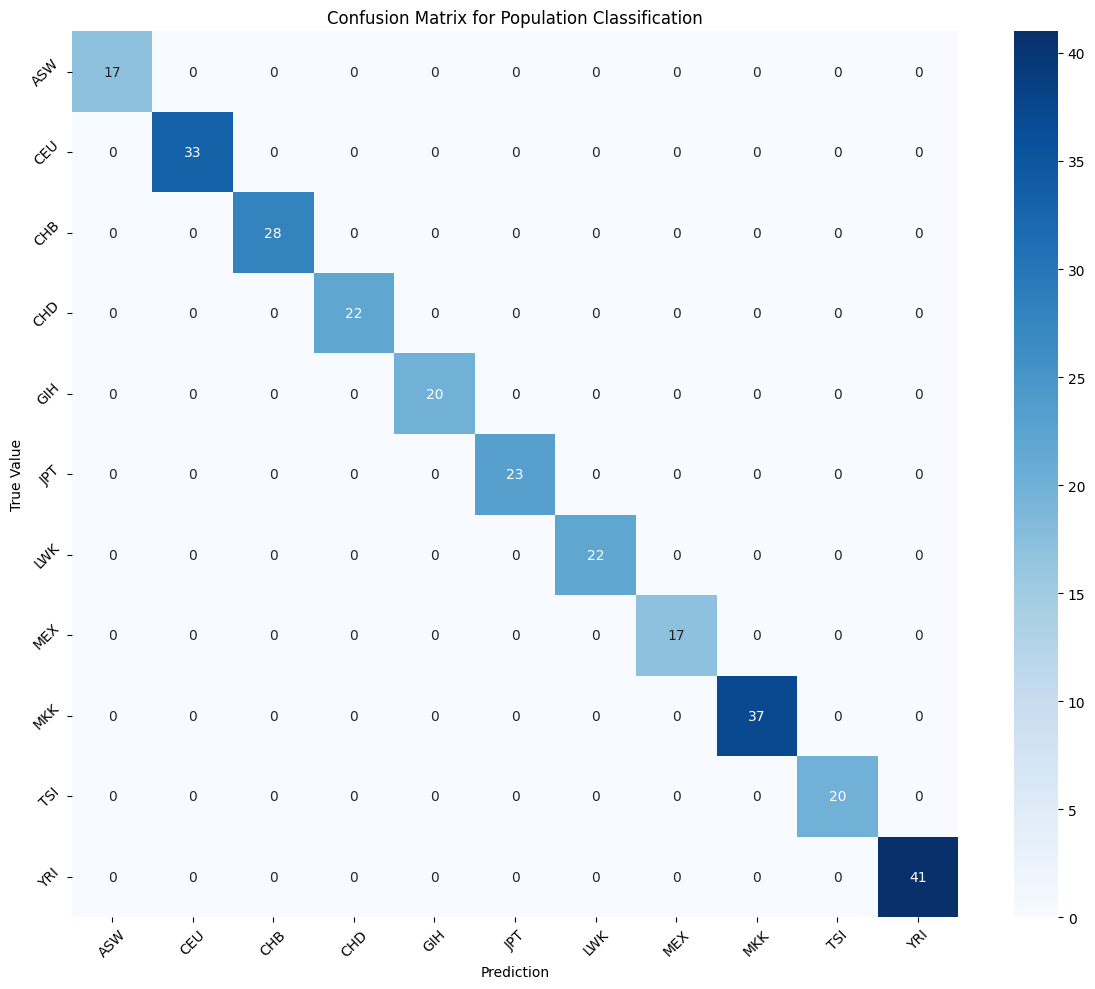

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=population_classes,
            yticklabels=population_classes)
plt.xlabel('Prediction')
plt.ylabel('True Value')
plt.title('Confusion Matrix for Population Classification')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'improved_confusion_matrix.png'))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall model accuracy: {accuracy:.4f}")

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Feature Importance Analysis
</div>


Top 10 features for classification:
PC_3: 0.1138
PC_5: 0.1098
PC_4: 0.1076
PC_6: 0.0955
PC_7: 0.0879
PC_1: 0.0852
PC_2: 0.0844
PC_9: 0.0830
PC_8: 0.0803
PC_10: 0.0780


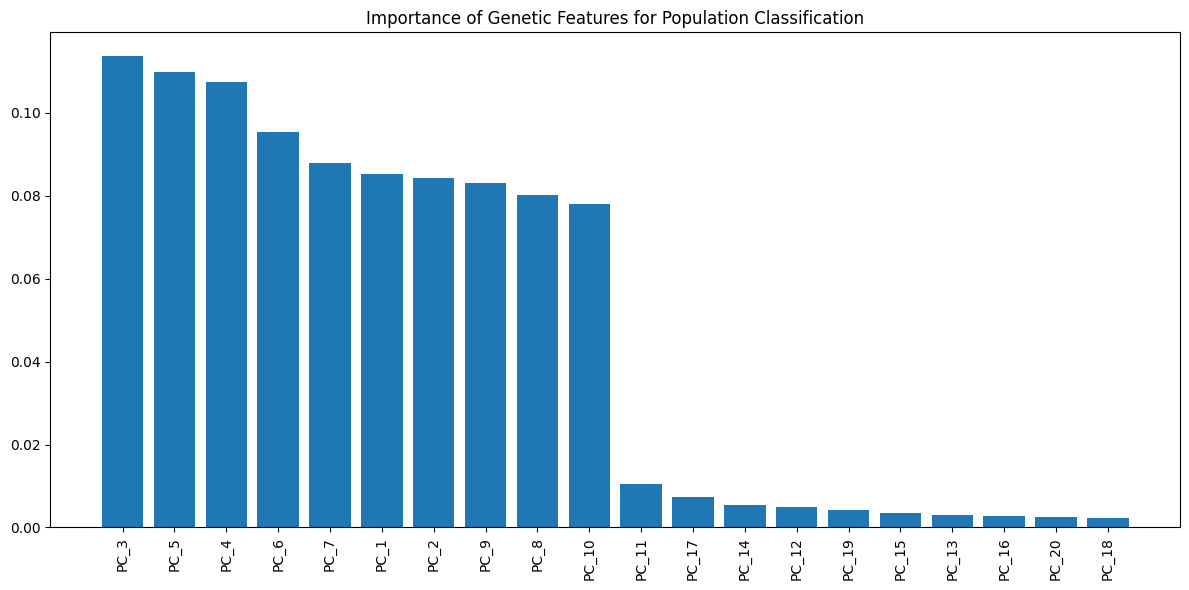

In [28]:
if hasattr(best_model['model'], 'feature_importances_'):
    importances = best_model['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print("\nTop 10 features for classification:")
    for i in range(min(10, len(feature_columns))):
        print(f"{feature_columns[indices[i]]}: {importances[indices[i]]:.4f}")
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(min(20, len(feature_columns))), 
            importances[indices[:20]], 
            align='center')
    plt.xticks(range(min(20, len(feature_columns))), 
              [feature_columns[i] for i in indices[:20]], 
              rotation=90)
    plt.title('Importance of Genetic Features for Population Classification')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'improved_feature_importance.png'))

<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
Gender Impact Analysis</div>

In [30]:
print("\nAnalyzing sex impact on classification accuracy:")
if 'SEX' in features_df.columns:
    all_preds = best_model.predict(X)
    features_df['Predicted_Population'] = le.inverse_transform(all_preds)
    
    for sex in sorted(features_df['SEX'].dropna().unique()):
        sex_mask = features_df['SEX'] == sex
        sex_data = features_df[sex_mask]
        if not sex_data.empty:
            sex_accuracy = (sex_data['Population'] == sex_data['Predicted_Population']).mean()
            sex_name = "Male" if sex == 1 else "Female" if sex == 2 else f"Unknown ({sex})"
            print(f"{sex_name}: accuracy = {sex_accuracy:.4f} ({sum(sex_mask)} samples)")


Analyzing sex impact on classification accuracy:
Male: accuracy = 1.0000 (683 samples)
Female: accuracy = 1.0000 (714 samples)


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
    Save Models
</div>

In [32]:
import joblib
best_model_file = os.path.join(output_dir, 'best_population_model.pkl')
encoder_file = os.path.join(output_dir, 'population_encoder.pkl')

joblib.dump(best_model, best_model_file)
joblib.dump(le, encoder_file)

print(f"\nBest model saved to: {best_model_file}")
print(f"Encoder information saved to: {encoder_file}")


Best model saved to: hapmap_data/improved_data/best_population_model.pkl
Encoder information saved to: hapmap_data/improved_data/population_encoder.pkl


<div style="
    background-color: #000000; 
    color: #ffffff;
    padding: 15px; 
    border-radius: 10px; 
    text-align: center;
    font-weight: bold;
    font-size: 20px;
    font-family: 'Poppins', sans-serif; 
">
     Final Predictions and Output
</div>

In [38]:
prediction_file = os.path.join(output_dir, 'improved_population_predictions.csv')

ensemble_preds_all = best_model.predict(X)
features_df['Predicted_Population_Ensemble'] = le.inverse_transform(ensemble_preds_all)

features_df.to_csv(prediction_file, index=False)
print(f"Data with predictions saved to: {prediction_file}")

df_pred = pd.read_csv('hapmap_data/improved_data/improved_population_predictions.csv')
df_pred.head()

Data with predictions saved to: hapmap_data/improved_data/improved_population_predictions.csv


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_47,PC_48,PC_49,PC_50,IID,Population,SEX,SEX_numeric,Predicted_Population,Predicted_Population_Ensemble
0,-3.286389,3.713345,7.049765,-12.667088,5.998000,30.017303,-1.501575,-2.149035,-3.272392,-1.167183,...,-2.031562,-1.236379,2.808205,-0.998481,NA17970,CHD,2,2,CHD,CHD
1,-3.494451,3.634145,7.593422,-12.322916,6.573741,31.443804,-1.267921,-2.161368,-3.426457,-1.647937,...,-0.130543,-1.415628,-0.079093,0.125505,NA17977,CHD,2,2,CHD,CHD
2,-4.045368,3.231223,6.887850,-13.563820,5.455442,30.670858,-2.038332,-3.588676,-2.946405,-1.416737,...,4.021130,1.998624,-3.030091,-3.991733,NA17981,CHD,2,2,CHD,CHD
3,-4.150055,4.417829,6.743321,-12.370662,5.632334,30.202576,-2.146959,-2.445946,-2.616384,-1.581615,...,0.741521,-0.181806,-0.288837,0.709196,NA17993,CHD,2,2,CHD,CHD
4,-3.332874,3.274309,7.858722,-12.730288,5.195930,31.210854,-2.136702,-2.004895,-3.455166,-2.218749,...,-0.601946,-0.008956,0.392524,-2.224247,NA18101,CHD,2,2,CHD,CHD


In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

class AncestryPredictor:
    """
    Class for predicting ancestry using the trained model
    """
    def __init__(self, model_path, encoder_path, features_path, selected_snps_path=None):
        """
        Initialize the class with the required file paths
        """
        print("Loading the ancestry prediction model...")
        
        # Load the model and encoder
        self.model = joblib.load(model_path)
        self.encoder = joblib.load(encoder_path)
        
        # Load the features data used for training
        self.features_df = pd.read_csv(features_path)
        
        # Load the selected SNPs if available
        self.selected_snps = None
        if selected_snps_path and os.path.exists(selected_snps_path):
            self.selected_snps = pd.read_csv(selected_snps_path)
        
        # Number of principal components (from training data)
        self.n_components = len([col for col in self.features_df.columns if col.startswith('PC_')])
        
        # Known populations for the model
        self.known_populations = list(self.encoder.classes_)
        
        print(f"Model loaded successfully.")
        print(f"Number of principal components: {self.n_components}")
        print(f"Known populations: {self.known_populations}")
    
    def predict_by_id(self, sample_id):
        """
        Predict ancestry using the sample ID present in the training data
        """
        if sample_id not in self.features_df['IID'].values:
            print(f"Error: Sample {sample_id} not found in the data.")
            return None, None
        
        # Extract data and make prediction
        sample_data = self.features_df[self.features_df['IID'] == sample_id]
        
        # Prepare features
        feature_cols = [col for col in sample_data.columns if col.startswith('PC_')]
        if 'SEX' in sample_data.columns:
            sample_data['SEX_numeric'] = sample_data['SEX'].fillna(0).astype(int)
            feature_cols.append('SEX_numeric')
        
        # Make prediction
        X = sample_data[feature_cols].values
        prediction = self.model.predict(X)[0]
        predicted_pop = self.encoder.inverse_transform([prediction])[0]
        
        # True population (if available)
        true_pop = None
        if 'Population' in sample_data.columns:
            true_pop = sample_data['Population'].values[0]
        
        return predicted_pop, true_pop
    
    def display_sample_prediction(self, sample_id):
        """
        Display prediction result for a specific sample
        """
        predicted_pop, true_pop = self.predict_by_id(sample_id)
        
        if predicted_pop is None:
            return
        
        print(f"\nSample: {sample_id}")
        print(f"Predicted ancestry: {predicted_pop}")
        
        if true_pop:
            print(f"True ancestry: {true_pop}")
            print(f"Prediction is {'Correct ✓' if predicted_pop == true_pop else 'Incorrect ✗'}")
    
    def get_available_samples(self, limit=10):
        """
        Display available sample IDs from the data
        """
        available_ids = self.features_df['IID'].unique().tolist()
        print(f"Number of available samples: {len(available_ids)}")
        print(f"Examples of available sample IDs:")
        
        for i, sample_id in enumerate(available_ids[:limit]):
            pop = "Unknown"
            if 'Population' in self.features_df.columns:
                pop = self.features_df[self.features_df['IID'] == sample_id]['Population'].values[0]
            print(f"{i+1}. {sample_id} ({pop})")
        
        return available_ids

# Function to check for required files
def check_required_files(model_dir):
    """
    Check for the required files in the specified directory
    """
    required_files = {
        'best_population_model.pkl': 'Population classification model',
        'population_encoder.pkl': 'Ancestry encoder',
        'genetic_features_pca.csv': 'Feature data'
    }
    
    optional_files = {
        'selected_snps.csv': 'Selected SNPs list'
    }
    
    # Check for required files
    for filename, description in required_files.items():
        filepath = os.path.join(model_dir, filename)
        if not os.path.exists(filepath):
            print(f"{description} is missing: {filepath}")
            return False
        else:
            print(f"{description} is present: {filepath}")
    
    # Check for optional files
    for filename, description in optional_files.items():
        filepath = os.path.join(model_dir, filename)
        if not os.path.exists(filepath):
            print(f"{description} is missing: {filepath}")
        else:
            print(f"{description} is present: {filepath}")
    
    return True

# Main function to run in Kaggle
def main():
    """
    Main function for ancestry prediction
    """
    print("=== Ancestry Prediction System from Genetic Data ===\n")
    
    # Set the model directory path
    # In Kaggle, it is better to use the absolute path to avoid path issues
    model_dir = '/kaggle/working/hapmap_data/improved_data'
    
    if not os.path.exists(model_dir):
        alternative_dir = 'hapmap_data/improved_data'
        if os.path.exists(alternative_dir):
            model_dir = alternative_dir
            print(f"Model directory path has been changed to: {model_dir}")
        else:
            print(f"Error: Model directory not found: {model_dir}")
            return
    
    # Check for required files
    if not check_required_files(model_dir):
        print("Some required files are missing. Ensure that the model has been trained first.")
        return
    
    # Load the model
    try:
        # File paths
        model_path = os.path.join(model_dir, 'best_population_model.pkl')
        encoder_path = os.path.join(model_dir, 'population_encoder.pkl')
        features_path = os.path.join(model_dir, 'genetic_features_pca.csv')
        selected_snps_path = os.path.join(model_dir, 'selected_snps.csv')
        
        # Initialize the predictor class
        predictor = AncestryPredictor(
            model_path=model_path,
            encoder_path=encoder_path,
            features_path=features_path,
            selected_snps_path=selected_snps_path
        )
        
        # Display available samples
        available_ids = predictor.get_available_samples(limit=20)
        
        # Test prediction on a sample
        if available_ids:
            print("\n=== Test Prediction ===")
            sample_id = available_ids[0]  # Use the first sample for testing
            predictor.display_sample_prediction(sample_id)
            
            # Allow user to input a sample ID for prediction
            while True:
                user_input = input("\nEnter a sample ID to predict (press q to quit): ")
                if user_input.lower() == 'q':
                    break
                predictor.display_sample_prediction(user_input)
        
    except Exception as e:
        print(f"❌ An error occurred while loading the model: {str(e)}")
        import traceback
        print(traceback.format_exc())

if __name__ == "__main__":
    main()


=== Ancestry Prediction System from Genetic Data ===

✓ Population classification model is present: /kaggle/working/hapmap_data/improved_data/best_population_model.pkl
✓ Ancestry encoder is present: /kaggle/working/hapmap_data/improved_data/population_encoder.pkl
✓ Feature data is present: /kaggle/working/hapmap_data/improved_data/genetic_features_pca.csv
✓ Selected SNPs list is present: /kaggle/working/hapmap_data/improved_data/selected_snps.csv
Loading the ancestry prediction model...
Model loaded successfully.
Number of principal components: 50
Known populations: ['ASW', 'CEU', 'CHB', 'CHD', 'GIH', 'JPT', 'LWK', 'MEX', 'MKK', 'TSI', 'YRI']
Number of available samples: 1397
Examples of available sample IDs:
1. NA17970 (CHD)
2. NA17977 (CHD)
3. NA17981 (CHD)
4. NA17993 (CHD)
5. NA18101 (CHD)
6. NA18105 (CHD)
7. NA18109 (CHD)
8. NA18129 (CHD)
9. NA18135 (CHD)
10. NA18139 (CHD)
11. NA18144 (CHD)
12. NA18150 (CHD)
13. NA18154 (CHD)
14. NA18162 (CHD)
15. NA17974 (CHD)
16. NA17975 (CHD)
17


Enter a sample ID to predict (press q to quit):  9


Error: Sample 9 not found in the data.



Enter a sample ID to predict (press q to quit):  NA17989



Sample: NA17989
Predicted ancestry: CHD
True ancestry: CHD
Prediction is Correct ✓



Enter a sample ID to predict (press q to quit):  NA19432



Sample: NA19432
Predicted ancestry: LWK
True ancestry: LWK
Prediction is Correct ✓


KeyboardInterrupt: Interrupted by user